In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings
import os

from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM
from neuralforecast.losses.pytorch import MSE, MAE

warnings.filterwarnings('ignore')
print("✅ Librerías cargadas.")

d:\programas\tfm\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 13:01:02,140	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-09 13:01:02,341	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


✅ Librerías cargadas.


In [2]:
# 1. Cargar datos
filename = "dataset_tfm_56_survivors.csv"

if os.path.exists(filename):
    df = pd.read_csv(filename)
    df['ds'] = pd.to_datetime(df['ds'])

    # Configuración Caso 3
    VAL_YEAR = 2023
    
    # --- FILTRO DE SEGURIDAD CRÍTICO ---
    # Calculamos cuántos datos tiene cada empresa
    counts = df.groupby('unique_id')['ds'].count().reset_index()
    counts.columns = ['unique_id', 'n_days']
    
    # Calculamos el mínimo necesario: 
    # Input(60) + Horizonte(5) + Validación(aprox 260 días laborales de 2023) + Margen seguridad(10)
    # Si una empresa tiene menos que esto, romperá el modelo al hacer el split.
    MIN_REQUIRED = 60 + 5 + 260 + 10 
    
    valid_ids = counts[counts['n_days'] > MIN_REQUIRED]['unique_id'].unique()
    dropped_ids = counts[counts['n_days'] <= MIN_REQUIRED]['unique_id'].unique()
    
    if len(dropped_ids) > 0:
        print(f"⚠️ FILTRANDO EMPRESAS CORTAS: Se eliminan {len(dropped_ids)} empresas por falta de historial.")
        print(f"   (IDs eliminados: {dropped_ids})")
        df = df[df['unique_id'].isin(valid_ids)].copy()
    
    print(f"✅ Empresas aptas para el modelo: {df['unique_id'].nunique()}")

    # 2. Filtro de Outliers y Normalización
    df = df[(df['y'] <= 0.5) & (df['y'] >= -0.5)].copy()

    stats = df.groupby('unique_id')['y'].agg(['mean', 'std']).reset_index()
    df = pd.merge(df, stats, on='unique_id', how='left')
    df['y_norm'] = (df['y'] - df['mean']) / (df['std'] + 1e-8)

    # 3. DataFrame Final
    df_final = df.copy()
    df_final['y_raw'] = df_final['y']
    df_final['y'] = df_final['y_norm']
    df_final = df_final[['unique_id', 'ds', 'y', 'y_raw']].dropna()
    df_final = df_final.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

    # 4. Preparar variables
    df_input = df_final.copy()
    
    # Calculamos el val_size basándonos en los datos FILTRADOS
    # Usamos la mediana de días en 2023 para tener un val_size estable
    val_size = len(df_input[(df_input['ds'].dt.year == VAL_YEAR) & (df_input['unique_id'] == df_input['unique_id'].iloc[0])])
    
    print("✅ Datos procesados.")
    print(f"   Tamaño Validación (2023): {val_size}")

else:
    print(f"❌ ERROR: No se encuentra el archivo '{filename}'.")

✅ Empresas aptas para el modelo: 56
✅ Datos procesados.
   Tamaño Validación (2023): 255


In [3]:
def ejecutar_grid_lstm(param_grid, df_train, val_size):
    print(f"\n🚀 INICIANDO GRID SEARCH PARA LSTM (Solo Caso 3)")
    print(f"   📂 Archivo de salida: grid_search_LSTM_case3.csv")
    
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    HORIZONTE = 5
    INPUT_SIZE_FIJO = 60

    for i, params in enumerate(combinations):
        print(f"   ⚙️ [{i+1}/{len(combinations)}] Probando: {params} ...", end=" ")
        
        try:
            model = LSTM(
                h=HORIZONTE,
                input_size=INPUT_SIZE_FIJO,
                loss=MSE(),
                valid_loss=MAE(),
                max_steps=300,
                scaler_type='identity',
                start_padding_enabled=True, # Mantenemos esto activo por seguridad
                
                # Mapeo correcto de parámetros
                encoder_hidden_size=params['hidden_size'], 
                decoder_hidden_size=params['hidden_size'],
                encoder_n_layers=params['n_layers'],
                decoder_layers=params['n_layers'],
                
                random_seed=42
            )
            
            nf = NeuralForecast(models=[model], freq='B')
            nf.fit(df=df_train, val_size=val_size)
            
            cutoff_date = f"{VAL_YEAR}-01-01"
            df_history = df_train[df_train['ds'] < cutoff_date].copy()
            forecasts = nf.predict(df=df_history).reset_index()
            
            combined = pd.merge(forecasts, df_train[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')
            col_pred = 'LSTM' 
            mae = (combined['y'] - combined[col_pred]).abs().mean()
            
            errors_per_id = combined.groupby('unique_id').apply(
                lambda x: (x['y'] - x[col_pred]).abs().mean()
            ).reset_index(name='MAE_Empresa')
            
            vol_data = []
            for uid in df_history['unique_id'].unique():
                # Verificación extra de longitud antes de calcular std
                series = df_history[df_history['unique_id']==uid]['y']
                if len(series) >= INPUT_SIZE_FIJO:
                    v = series.tail(INPUT_SIZE_FIJO).std()
                else:
                    v = 0 # Fallback si la serie es muy corta (no debería pasar con el filtro)
                vol_data.append({'unique_id': uid, 'Input_Vol': v})
            
            df_vol = pd.DataFrame(vol_data)
            analysis = pd.merge(df_vol, errors_per_id, on='unique_id')
            corr = analysis['Input_Vol'].corr(analysis['MAE_Empresa'])
            
            print(f"✅ MAE: {mae:.5f} | Corr: {corr:.4f}")
            
            res = params.copy()
            res['MAE'] = mae
            res['Correlacion'] = corr
            results.append(res)
            
        except Exception as e:
            print(f"❌ Error: {e}")

    if results:
        df_res = pd.DataFrame(results).sort_values('MAE')
        df_res.to_csv("grid_search_LSTM_case3.csv", index=False)
        print(f"\n🏆 MEJOR CONFIGURACIÓN LSTM: MAE {df_res.iloc[0]['MAE']:.5f}")

In [4]:
grid_lstm_params = {
    'hidden_size': [64, 128, 256, 512], 
    'n_layers': [1, 2, 3, 4]
}
print("📋 Parámetros cargados.")

📋 Parámetros cargados.


In [5]:
ejecutar_grid_lstm(grid_lstm_params, df_input, val_size)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MSE           | 0      | train | 0    
1 | valid_loss   | MAE           | 0      | train | 0    
2 | padder_train | ConstantPad1d | 0      | train | 0    
3 | scaler       | TemporalNorm  | 0      | train | 0    
4 | hist_encoder | LSTM          | 17.2 K | train | 0    
5 | mlp_decoder  | MLP           | 4.2 K  | train | 0    
---------------------------------------------------------------
21.4 K    Trainable params
0         Non-trainable params
21.4 K    Total params
0.086     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops



🚀 INICIANDO GRID SEARCH PARA LSTM (Solo Caso 3)
   📂 Archivo de salida: grid_search_LSTM_case3.csv
Epoch 149: 100%|██████████| 2/2 [00:00<00:00, 21.09it/s, v_num=3, train_loss_step=1.040, train_loss_epoch=1.050, valid_loss=0.548] 

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 149: 100%|██████████| 2/2 [00:00<00:00, 20.87it/s, v_num=3, train_loss_step=1.040, train_loss_epoch=1.050, valid_loss=0.548]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

✅ MAE: 0.68005 | Corr: 0.3634
Epoch 149: 100%|██████████| 2/2 [00:05<00:00,  0.39it/s, v_num=33, train_loss_step=1.040, train_loss_epoch=1.040, valid_loss=0.548]

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 149: 100%|██████████| 2/2 [00:05<00:00,  0.39it/s, v_num=33, train_loss_step=1.040, train_loss_epoch=1.040, valid_loss=0.548]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 49.67it/s]
✅ MAE: 0.68070 | Corr: 0.3633

🏆 MEJOR CONFIGURACIÓN LSTM: MAE 0.67226


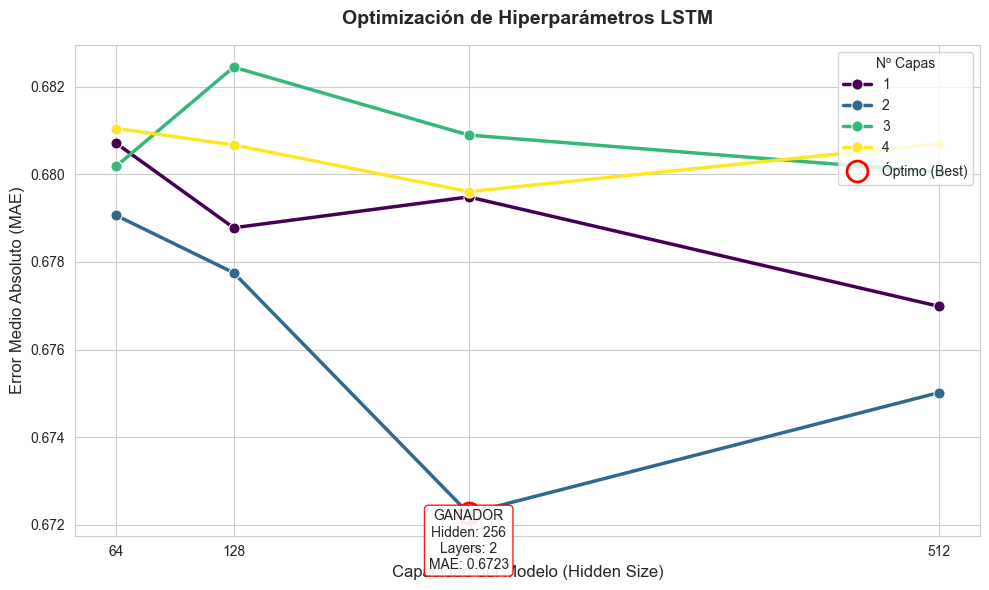

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CARGA MANUAL DE TUS DATOS (Los que me has pasado)
data = {
    'hidden_size': [256, 512, 512, 128, 128, 64, 256, 256, 512, 64, 128, 512, 64, 256, 64, 128],
    'n_layers': [2, 2, 1, 2, 1, 2, 1, 4, 3, 3, 4, 4, 1, 3, 4, 3],
    'MAE': [
        0.6722627889117805, 0.675018117463417, 0.6769875268737675, 
        0.6777530714453109, 0.6787793106049609, 0.6790615056492534, 
        0.6794826992638555, 0.6796033020242459, 0.6800452482324236, 
        0.6801823784176203, 0.6806689073309777, 0.6806958799361593, 
        0.6807081112732184, 0.6808942827074864, 0.6810436432494059, 
        0.6824434666780546
    ]
}

df_results = pd.DataFrame(data)

# 2. CONFIGURACIÓN DEL GRÁFICO ACADÉMICO
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Usamos un Lineplot para ver la tendencia
# Eje X: Tamaño Oculto (Hidden Size)
# Eje Y: Error (MAE)
# Colores (Hue): Número de Capas (Layers)
ax = sns.lineplot(
    data=df_results, 
    x='hidden_size', 
    y='MAE', 
    hue='n_layers', 
    palette='viridis', 
    marker='o', 
    linewidth=2.5,
    markersize=8
)

# 3. DESTACAR EL GANADOR (256, 2)
best_row = df_results.loc[df_results['MAE'].idxmin()]

# Círculo rojo alrededor del ganador
plt.plot(best_row['hidden_size'], best_row['MAE'], 'o', 
         ms=15, mfc='none', mec='red', mew=2, label='Óptimo (Best)')

# Anotación con flecha
plt.annotate(
    f"GANADOR\nHidden: {int(best_row['hidden_size'])}\nLayers: {int(best_row['n_layers'])}\nMAE: {best_row['MAE']:.4f}",
    xy=(best_row['hidden_size'], best_row['MAE']),
    xytext=(0, -40), textcoords='offset points',
    ha='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color='red', connectionstyle="arc3,rad=.2")
)

# 4. FORMATO FINAL
plt.title('Optimización de Hiperparámetros LSTM', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Error Medio Absoluto (MAE)', fontsize=12)
plt.xlabel('Capacidad del Modelo (Hidden Size)', fontsize=12)
plt.xticks([64, 128, 256, 512]) # Forzamos que salgan solo los valores probados
plt.legend(title='Nº Capas', loc='upper right')

plt.tight_layout()
plt.savefig('grid_search_lstm_results.png', dpi=300)
plt.show()